# Naive Bayes Classifier for Facial Emotion Recognition

## Overview
This notebook implements a Gaussian Naive Bayes classifier for emotion recognition using preprocessed LBP (Local Binary Pattern) features.

## Pipeline
1. **Load preprocessed LBP features** - Already extracted and normalized histogram features
2. **PCA dimensionality reduction** - Retain 95% of variance (recommended default)
3. **Baseline Naive Bayes** - Train with default hyperparameters
4. **Hyperparameter tuning** - Grid search over `var_smoothing` parameter using validation set
5. **Evaluation** - Compare baseline vs tuned on test set

## Key Notes
- **No StandardScaler needed**: LBP histogram features are already normalized during preprocessing
- **PCA n_components=0.95**: Retains 95% of variance (good default per preprocessing example)
- **Train/Val/Test split**: Already provided by `load_grouped_splits()`
- **Final training**: After tuning, model is refit on train+val for better generalization

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from train_test_split import load_grouped_splits

from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# reproducibility
np.random.seed(42)

In [74]:
# Load preprocessed LBP features with train/val/test splits
# Note: Features are already normalized LBP histograms, no StandardScaler needed
X_train, y_train, X_val, y_val, X_test, y_test, classes = load_grouped_splits()

print("Loaded preprocessed LBP data:")
print(f"  - Training samples: {X_train.shape[0]}")
print(f"  - Validation samples: {X_val.shape[0]}")
print(f"  - Test samples: {X_test.shape[0]}")
print(f"  - Feature dimension: {X_train.shape[1]}")
print(f"  - Number of classes: {len(classes)}")
print(f"  - Class names: {classes}")

# Baseline pipeline (no tuning): PCA -> GaussianNB (default params)
# Note: No StandardScaler - LBP histograms are already normalized
baseline_pipe = Pipeline([
    ("pca", PCA(n_components=0.95)),  # Retain 95% variance (recommended default)
    ("clf", GaussianNB())
])

baseline_pipe.fit(X_train, y_train)

# Check actual PCA components used
n_components_used = baseline_pipe.named_steps["pca"].n_components_
print(f"\nPCA reduced features from {X_train.shape[1]} to {n_components_used} components")

y_val_pred_baseline = baseline_pipe.predict(X_val)
y_test_pred_baseline = baseline_pipe.predict(X_test)

print("\nBaseline (default GaussianNB, var_smoothing=1e-9):")
print(f"  Val accuracy:  {accuracy_score(y_val, y_val_pred_baseline)*100:.2f}%")
print(f"  Test accuracy: {accuracy_score(y_test, y_test_pred_baseline)*100:.2f}%")
print("\nTest classification report:")
print(classification_report(y_test, y_test_pred_baseline, target_names=classes))

Train size: 96
Validation size: 24
Test size: 32
Loaded preprocessed LBP data:
  - Training samples: 96
  - Validation samples: 24
  - Test samples: 32
  - Feature dimension: 16384
  - Number of classes: 8
  - Class names: ['Anger' 'Contempt' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprised']

PCA reduced features from 16384 to 62 components

Baseline (default GaussianNB, var_smoothing=1e-9):
  Val accuracy:  20.83%
  Test accuracy: 25.00%

Test classification report:
              precision    recall  f1-score   support

       Anger       0.00      0.00      0.00         4
    Contempt       0.00      0.00      0.00         4
     Disgust       0.67      0.50      0.57         4
        Fear       0.25      0.25      0.25         4
       Happy       1.00      0.50      0.67         4
     Neutral       0.10      0.25      0.14         4
         Sad       0.00      0.00      0.00         4
   Surprised       0.50      0.50      0.50         4

    accuracy                        

c:\Users\Lars Magne\Informatikk\Andre_ar\Datadrevet Programvare\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lars Magne\Informatikk\Andre_ar\Datadrevet Programvare\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lars Magne\Informatikk\Andre_ar\Datadrevet Programvare\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

In [75]:
# Hyperparameter tuning with GridSearchCV using validation set
# Combine train+val for GridSearchCV with explicit validation fold
X_comb = np.vstack([X_train, X_val])
y_comb = np.hstack([y_train, y_val])
test_fold = np.array([-1]*len(X_train) + [0]*len(X_val))   # -1 = train, 0 = val
ps = PredefinedSplit(test_fold)

print(f"Combined training set for GridSearch: {len(X_comb)} samples")
print(f"  - Training fold: {len(X_train)} samples")
print(f"  - Validation fold: {len(X_val)} samples")

pipe = Pipeline([
    ("pca", PCA(n_components=0.95)),
    ("clf", GaussianNB())
])

# Grid: include default (1e-9) and explore neighborhood
param_grid = {"clf__var_smoothing": np.logspace(-12, -3, 30)}

print(f"\nSearching {len(param_grid['clf__var_smoothing'])} var_smoothing values...")
gs = GridSearchCV(pipe, param_grid, cv=ps, scoring="accuracy", n_jobs=-1, refit=True, verbose=1)
gs.fit(X_comb, y_comb)   # uses predefined split for validation, refits best model on train+val

print("\nTuned model (GridSearchCV):")
print(f"  Best var_smoothing: {gs.best_params_['clf__var_smoothing']:.2e}")
print(f"  Best val score: {gs.best_score_*100:.2f}%")

# Check actual PCA components used
best = gs.best_estimator_
n_components_tuned = best.named_steps["pca"].n_components_
print(f"  PCA components: {n_components_tuned}")

# Final eval on test
y_test_pred_tuned = best.predict(X_test)
test_acc_tuned = accuracy_score(y_test, y_test_pred_tuned)
print(f"\nFinal test accuracy: {test_acc_tuned*100:.2f}%")
print("\nTest classification report:")
print(classification_report(y_test, y_test_pred_tuned, target_names=classes))

Combined training set for GridSearch: 120 samples
  - Training fold: 96 samples
  - Validation fold: 24 samples

Searching 30 var_smoothing values...
Fitting 1 folds for each of 30 candidates, totalling 30 fits

Tuned model (GridSearchCV):
  Best var_smoothing: 1.00e-12
  Best val score: 20.83%
  PCA components: 76

Final test accuracy: 37.50%

Test classification report:
              precision    recall  f1-score   support

       Anger       0.30      0.75      0.43         4
    Contempt       0.25      0.25      0.25         4
     Disgust       1.00      0.50      0.67         4
        Fear       0.50      0.25      0.33         4
       Happy       1.00      0.25      0.40         4
     Neutral       0.29      0.50      0.36         4
         Sad       0.00      0.00      0.00         4
   Surprised       0.67      0.50      0.57         4

    accuracy                           0.38        32
   macro avg       0.50      0.38      0.38        32
weighted avg       0.50      

In [76]:
import pandas as pd

# Compare baseline vs tuned model performance
comparison = pd.DataFrame({
    "Model": ["Baseline (var_smoothing=1e-9)", "Tuned (GridSearch)"],
    "Val Accuracy": [
        f"{accuracy_score(y_val, y_val_pred_baseline)*100:.2f}%",
        f"{gs.best_score_*100:.2f}%"
    ],
    "Test Accuracy": [
        f"{accuracy_score(y_test, y_test_pred_baseline)*100:.2f}%",
        f"{accuracy_score(y_test, y_test_pred_tuned)*100:.2f}%"
    ]
})

print("\n" + "="*60)
print("Baseline vs Tuned Model Comparison")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

# Show improvement (or degradation)
baseline_test = accuracy_score(y_test, y_test_pred_baseline)
tuned_test = accuracy_score(y_test, y_test_pred_tuned)
diff = (tuned_test - baseline_test) * 100
if diff > 0:
    print(f"\n✓ Tuning improved test accuracy by {diff:.2f} percentage points")
elif diff < 0:
    print(f"\n✗ Tuning decreased test accuracy by {abs(diff):.2f} percentage points")
else:
    print(f"\n= No change in test accuracy")
print("="*60)


Baseline vs Tuned Model Comparison
                        Model Val Accuracy Test Accuracy
Baseline (var_smoothing=1e-9)       20.83%        25.00%
           Tuned (GridSearch)       20.83%        37.50%

✓ Tuning improved test accuracy by 12.50 percentage points


In [77]:
# Inspect grid search results to understand tuning behavior
import pandas as pd

cvres = pd.DataFrame(gs.cv_results_)[["param_clf__var_smoothing", "mean_test_score", "std_test_score"]]
cvres = cvres.sort_values("mean_test_score", ascending=False)

print("Top 10 var_smoothing values by validation accuracy:")
print(cvres.head(10))

print("\n" + "="*60)
print(f"Default var_smoothing (1e-9) performance:")
default_row = cvres[cvres["param_clf__var_smoothing"] == 1e-9]
if not default_row.empty:
    print(f"  Validation accuracy: {default_row['mean_test_score'].values[0]*100:.2f}%")
    rank = (cvres["mean_test_score"] > default_row["mean_test_score"].values[0]).sum() + 1
    print(f"  Rank: {rank} out of {len(cvres)}")
else:
    print("  Default value not in grid")
print("="*60)

Top 10 var_smoothing values by validation accuracy:
   param_clf__var_smoothing  mean_test_score  std_test_score
0              1.000000e-12         0.208333             0.0
1              2.043360e-12         0.208333             0.0
2              4.175319e-12         0.208333             0.0
3              8.531679e-12         0.208333             0.0
4              1.743329e-11         0.208333             0.0
5              3.562248e-11         0.208333             0.0
6              7.278954e-11         0.208333             0.0
7              1.487352e-10         0.208333             0.0
8              3.039195e-10         0.208333             0.0
9              6.210169e-10         0.208333             0.0

Default var_smoothing (1e-9) performance:
  Default value not in grid


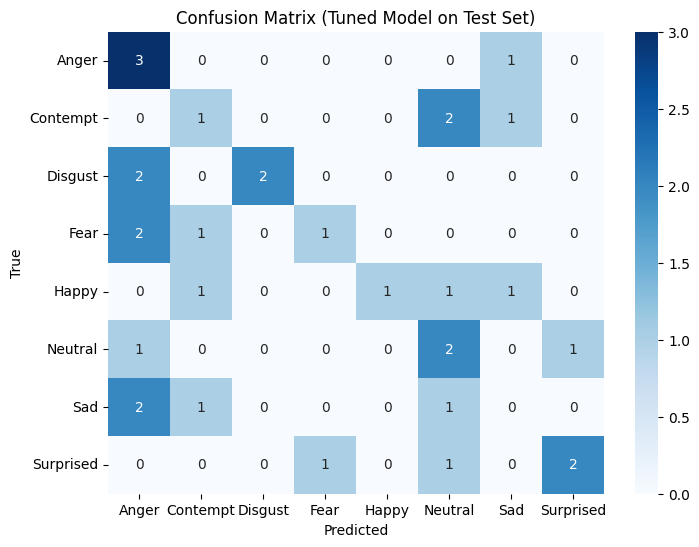

In [78]:
cm = confusion_matrix(y_test, y_test_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Tuned Model on Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

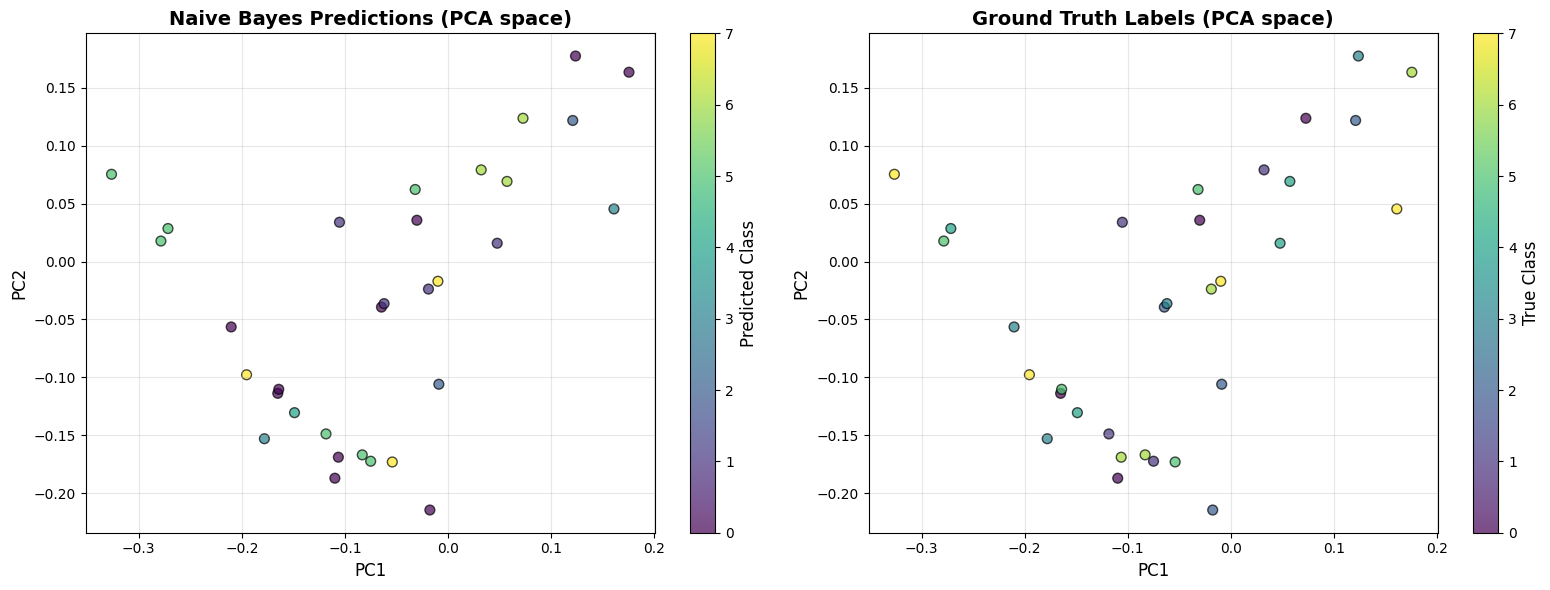

In [79]:
# Visualize test predictions in PCA-reduced space (first 2 components)
# Extract PCA transform from tuned pipeline for visualization
X_test_pca = best.named_steps["pca"].transform(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Predictions
scatter1 = ax1.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pred_tuned, 
                       cmap='viridis', alpha=0.7, edgecolors='k', s=50)
ax1.set_title('Naive Bayes Predictions (PCA space)', fontsize=14, fontweight='bold')
ax1.set_xlabel("PC1", fontsize=12)
ax1.set_ylabel("PC2", fontsize=12)
cbar1 = plt.colorbar(scatter1, ax=ax1, ticks=range(len(classes)))
cbar1.set_label('Predicted Class', fontsize=12)
ax1.grid(alpha=0.3)

# Plot 2: Ground truth
scatter2 = ax2.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, 
                       cmap='viridis', alpha=0.7, edgecolors='k', s=50)
ax2.set_title('Ground Truth Labels (PCA space)', fontsize=14, fontweight='bold')
ax2.set_xlabel("PC1", fontsize=12)
ax2.set_ylabel("PC2", fontsize=12)
cbar2 = plt.colorbar(scatter2, ax=ax2, ticks=range(len(classes)))
cbar2.set_label('True Class', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()